# Prédiction du Turnover des Employés — Notebook 3
## Interprétabilité du modèle avec SHAP

**Projet Capstone M2 — Jebari Oussema**

---

Ce notebook a pour objectif d'interpréter les prédictions du **Random Forest optimisé** (retenu dans le
Notebook 2) à l'aide de **SHAP (SHapley Additive exPlanations)**, une technique d'interprétabilité basée
sur la théorie des jeux coopératifs qui quantifie la contribution de chaque variable à chaque prédiction.

**Plan :**
1. Reproduction du pipeline de données et réentraînement du Random Forest optimisé
2. Calcul des valeurs SHAP avec `shap.TreeExplainer`
3. Interprétation **globale** : quelles variables influencent le plus le modèle en général ?
4. Interprétation **locale** : pourquoi le modèle prédit-il un risque élevé pour des employés spécifiques ?
5. Synthèse et recommandations RH

---
## ÉTAPE 0 — Setup de l'environnement

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, classification_report
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
SEUIL_OPTIMAL = 0.388  # seuil de décision optimisé dans le Notebook 2

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librairies importées avec succès !')
print(f'Version SHAP : {shap.__version__}')

Librairies importées avec succès !
Version SHAP : 0.52.0


---
## ÉTAPE 1 — Reproduction du pipeline de données

On reproduit ici exactement le même pipeline de préparation des données que dans le Notebook 2 :
suppression des colonnes inutiles, encodage one-hot, split 80/20 stratifié, standardisation,
puis SMOTE sur le train uniquement.

In [2]:
# Chargement du dataset
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Suppression des colonnes inutiles (constantes + identifiant)
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])

# Encodage de la variable cible
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding des variables catégorielles
colonnes_cat = df.select_dtypes(include='object').columns.tolist()
df_encode = pd.get_dummies(df, columns=colonnes_cat, drop_first=True)

# Séparation X / y
X = df_encode.drop(columns=['Attrition'])
y = df_encode['Attrition']

# Split train/test 80/20 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Standardisation (fit sur le train uniquement)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

# SMOTE sur le train uniquement
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Dimensions du jeu de test : {X_test_scaled.shape}')
print(f'Variables explicatives : {X_test_scaled.shape[1]}')
print(f"Répartition y_test : {y_test.value_counts().to_dict()}")

Dimensions du jeu de test : (294, 44)
Variables explicatives : 44
Répartition y_test : {0: 247, 1: 47}


---
## ÉTAPE 2 — Réentraînement du Random Forest optimisé

On réentraîne le Random Forest avec les **hyperparamètres optimaux** identifiés dans le Notebook 2
via `RandomizedSearchCV` (scoring=`f1`, cv=5) :

| Hyperparamètre | Valeur optimale |
|---|---|
| `n_estimators` | 200 |
| `max_depth` | 5 |
| `min_samples_split` | 2 |
| `min_samples_leaf` | 2 |
| `class_weight` | 'balanced' |

Le modèle est entraîné sur `X_train_sm` / `y_train_sm` (jeu d'entraînement après SMOTE).
Les prédictions finales utilisent le **seuil optimal = 0.388** (maximise le F1-score sur le jeu de test).

In [3]:
# Réentraînement du Random Forest avec les hyperparamètres optimaux du Notebook 2
rf_optimal = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
rf_optimal.fit(X_train_sm, y_train_sm)

# Vérification des performances (cohérence avec le Notebook 2)
y_proba_test = rf_optimal.predict_proba(X_test_scaled)[:, 1]
y_pred_opt = (y_proba_test >= SEUIL_OPTIMAL).astype(int)

print('Performance du Random Forest optimisé (seuil = 0.388) :')
print(f'  F1-score : {f1_score(y_test, y_pred_opt):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred_opt):.4f}')
print()
print(classification_report(y_test, y_pred_opt, target_names=['No (0)', 'Yes (1)']))

Performance du Random Forest optimisé (seuil = 0.388) :
  F1-score : 0.5072
  Recall   : 0.7447

              precision    recall  f1-score   support

      No (0)       0.94      0.77      0.85       247
     Yes (1)       0.38      0.74      0.51        47

    accuracy                           0.77       294
   macro avg       0.66      0.76      0.68       294
weighted avg       0.85      0.77      0.79       294



---
## ÉTAPE 3 — Calcul des valeurs SHAP avec `TreeExplainer`

`shap.TreeExplainer` est optimisé pour les modèles à base d'arbres (Random Forest, XGBoost, etc.).
Il calcule les valeurs SHAP **exactes** (et non des approximations) en exploitant la structure
arborescente du modèle, ce qui le rend rapide et précis.

**Interprétation d'une valeur SHAP :**
- Une valeur SHAP positive pour une variable signifie qu'elle **augmente** la probabilité de départ.
- Une valeur SHAP négative signifie qu'elle **diminue** la probabilité de départ.
- L'amplitude indique l'intensité de l'impact.

Les valeurs SHAP sont calculées sur le **jeu de test** (données réelles non vues pendant l'entraînement),
pour la classe d'intérêt : **Attrition = Yes (1)**.

In [4]:
# Création de l'explicateur SHAP pour les modèles à base d'arbres
explainer = shap.TreeExplainer(rf_optimal)

# Calcul des valeurs SHAP sur le jeu de test
# shap_values : tableau de forme (n_échantillons, n_variables, n_classes)
shap_values = explainer.shap_values(X_test_scaled)

print(f'Shape des valeurs SHAP : {shap_values.shape}')
print('  -> (n_échantillons, n_variables, n_classes) = '
      f'({shap_values.shape[0]}, {shap_values.shape[1]}, {shap_values.shape[2]})')

# Extraction des valeurs SHAP pour la classe 1 (Attrition = Yes)
shap_class1 = shap_values[:, :, 1]
print(f'\nShape pour la classe "Yes" : {shap_class1.shape}')

# Valeur de base (prédiction moyenne du modèle = référence sans information)
expected_val = float(explainer.expected_value[1])
print(f'Valeur de base (expected_value, classe "Yes") : {expected_val:.4f}')
print('(correspond à la probabilité moyenne de départ dans le jeu d\'entraînement)')

Shape des valeurs SHAP : (294, 44, 2)
  -> (n_échantillons, n_variables, n_classes) = (294, 44, 2)

Shape pour la classe "Yes" : (294, 44)
Valeur de base (expected_value, classe "Yes") : 0.4989
(correspond à la probabilité moyenne de départ dans le jeu d'entraînement)


---
## ÉTAPE 4 — Interprétation globale

L'interprétation globale répond à la question : **quelles variables influencent le plus les prédictions
du modèle, et dans quel sens ?**

Deux visualisations complémentaires :
- **Beeswarm plot** (summary plot) : affiche la distribution des valeurs SHAP pour chaque variable.
  Chaque point représente un employé. La couleur indique la valeur de la variable (rouge = valeur élevée,
  bleu = valeur faible).
- **Bar plot** : résume l'importance moyenne (|SHAP|) de chaque variable en un seul chiffre.

### 4.1 SHAP Beeswarm Plot (Summary Plot)

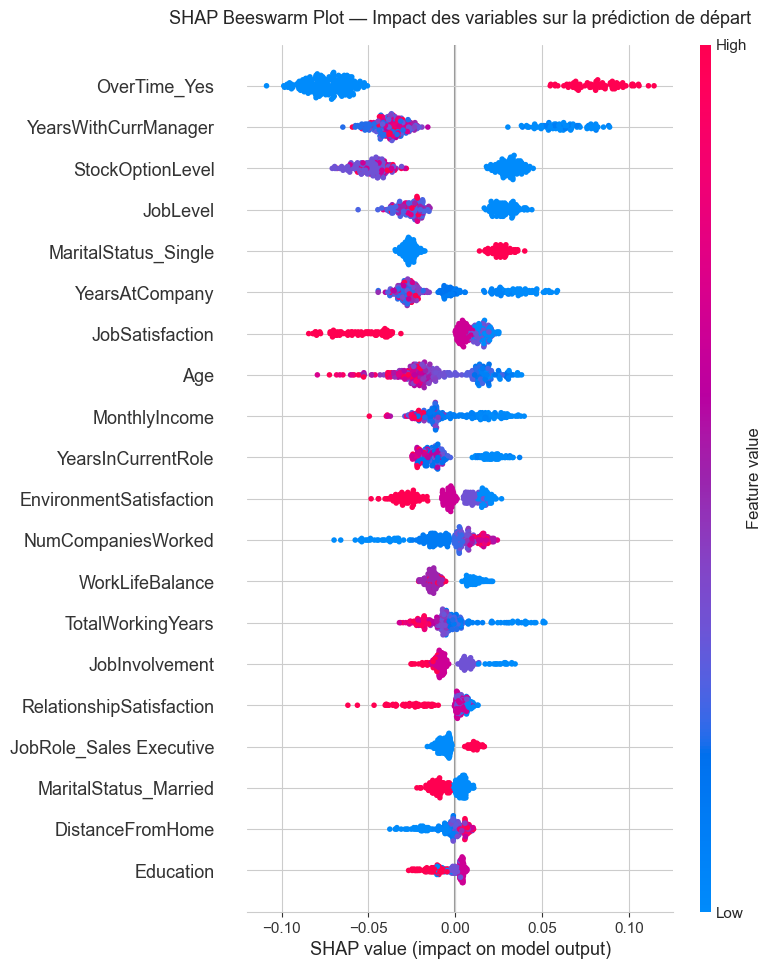

fig14_shap_summary_beeswarm.png sauvegardé (300 dpi)


In [5]:
# SHAP Beeswarm plot — impact de chaque variable sur la prédiction de départ
# Chaque point = un employé du jeu de test
# Axe X = valeur SHAP (impact sur la probabilité de départ)
# Couleur = valeur réelle de la variable (rouge = élevée, bleu = faible)

shap.summary_plot(shap_class1, X_test_scaled, max_display=20, show=False)
plt.title('SHAP Beeswarm Plot — Impact des variables sur la prédiction de départ', fontsize=13, pad=15)
plt.savefig('../figures/fig14_shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('fig14_shap_summary_beeswarm.png sauvegardé (300 dpi)')

### 4.2 SHAP Bar Plot — Importance moyenne des 15 premières variables

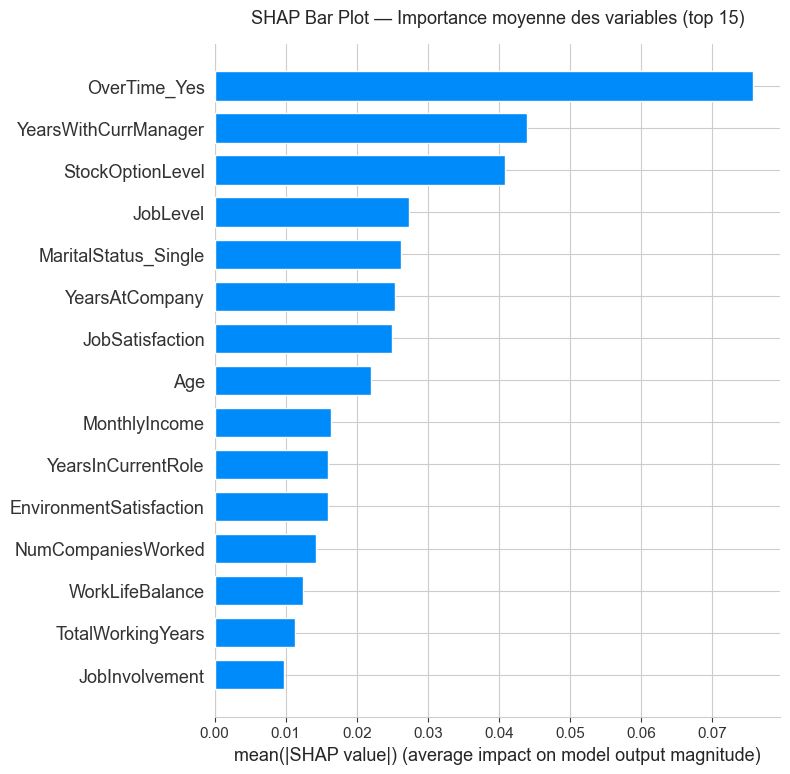

fig15_shap_importance_variables.png sauvegardé (300 dpi)


In [6]:
# SHAP Bar plot — importance moyenne absolue (|SHAP|) des 15 variables les plus influentes
shap.summary_plot(shap_class1, X_test_scaled, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Bar Plot — Importance moyenne des variables (top 15)', fontsize=13, pad=15)
plt.savefig('../figures/fig15_shap_importance_variables.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('fig15_shap_importance_variables.png sauvegardé (300 dpi)')

---
## ÉTAPE 5 — Interprétation locale (Waterfall Plots)

L'interprétation locale répond à la question : **pourquoi le modèle a-t-il prédit un risque élevé de
départ pour CET employé spécifique ?**

Le **waterfall plot** décompose la prédiction d'un employé en contributions individuelles de chaque
variable, à partir de la valeur de base (`E[f(x)]` = probabilité moyenne).
- Les barres rouges (positives) poussent vers un risque de départ plus élevé.
- Les barres bleues (négatives) poussent vers un risque plus faible.

On sélectionne les **3 employés du jeu de test** classés à risque avec les probabilités de départ
les plus élevées (selon le modèle optimisé, seuil = 0.388).

In [7]:
# Sélection des 3 employés à risque élevé (probabilités les plus hautes parmi les prédits "Yes")
y_pred_opt = (y_proba_test >= SEUIL_OPTIMAL).astype(int)
risque_idx = np.where(y_pred_opt == 1)[0]

# Tri par probabilité décroissante
top3_idx = risque_idx[np.argsort(y_proba_test[risque_idx])[::-1]][:3]

print(f"Employés classés 'à risque' (seuil={SEUIL_OPTIMAL}) : {len(risque_idx)} sur {len(y_test)}")
print(f"\nTop 3 employés les plus à risque :")
for rank, idx in enumerate(top3_idx):
    realite = 'Départ réel (Yes)' if y_test.iloc[idx] == 1 else 'Pas de départ (No)'
    print(f"  #{rank+1} (indice {idx}) : P(départ) = {y_proba_test[idx]:.3f} | Réalité : {realite}")

# Construction de l'objet Explanation SHAP pour les waterfall plots
shap_exp = shap.Explanation(
    values=shap_class1,
    base_values=np.full(len(X_test_scaled), expected_val),
    data=X_test_scaled.values,
    feature_names=X_test_scaled.columns.tolist()
)

Employés classés 'à risque' (seuil=0.388) : 91 sur 294

Top 3 employés les plus à risque :
  #1 (indice 200) : P(départ) = 0.882 | Réalité : Départ réel (Yes)
  #2 (indice 276) : P(départ) = 0.881 | Réalité : Départ réel (Yes)
  #3 (indice 223) : P(départ) = 0.844 | Réalité : Pas de départ (No)


### 5.1 Employé à risque #1

Employé #1 — Indice : 200 | P(départ) = 0.882 | Réalité : Oui


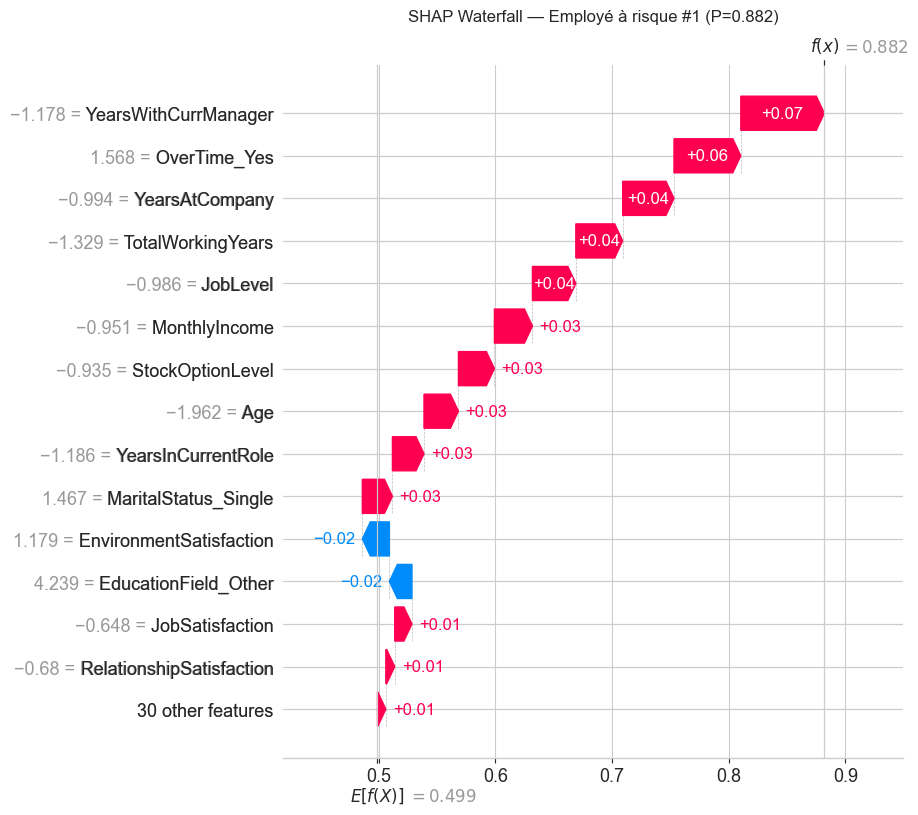

fig16_shap_waterfall_employe_1.png sauvegardé (300 dpi)


In [8]:
idx1 = top3_idx[0]
print(f"Employé #1 — Indice : {idx1} | P(départ) = {y_proba_test[idx1]:.3f} | "
      f"Réalité : {'Oui' if y_test.iloc[idx1]==1 else 'Non'}")

shap.plots.waterfall(shap_exp[idx1], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Employé à risque #1 (P={y_proba_test[idx1]:.3f})', fontsize=12, pad=10)
plt.savefig('../figures/fig16_shap_waterfall_employe_1.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('fig16_shap_waterfall_employe_1.png sauvegardé (300 dpi)')

### 5.2 Employé à risque #2

Employé #2 — Indice : 276 | P(départ) = 0.881 | Réalité : Oui


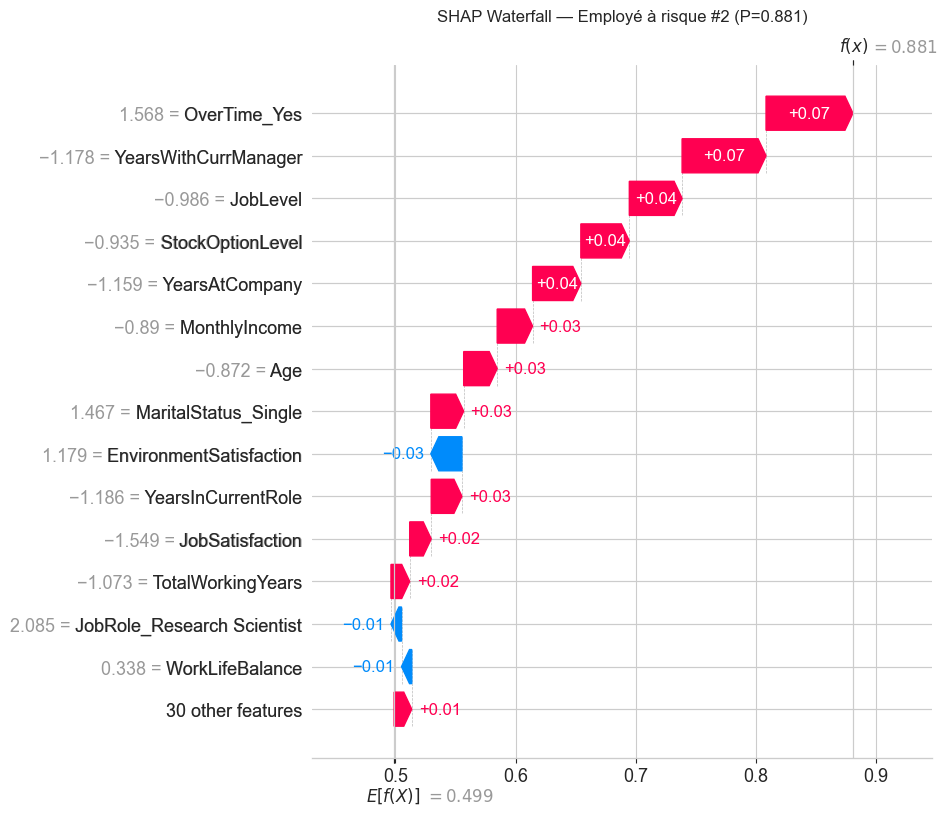

fig17_shap_waterfall_employe_2.png sauvegardé (300 dpi)


In [9]:
idx2 = top3_idx[1]
print(f"Employé #2 — Indice : {idx2} | P(départ) = {y_proba_test[idx2]:.3f} | "
      f"Réalité : {'Oui' if y_test.iloc[idx2]==1 else 'Non'}")

shap.plots.waterfall(shap_exp[idx2], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Employé à risque #2 (P={y_proba_test[idx2]:.3f})', fontsize=12, pad=10)
plt.savefig('../figures/fig17_shap_waterfall_employe_2.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('fig17_shap_waterfall_employe_2.png sauvegardé (300 dpi)')

### 5.3 Employé à risque #3

Employé #3 — Indice : 223 | P(départ) = 0.844 | Réalité : Non


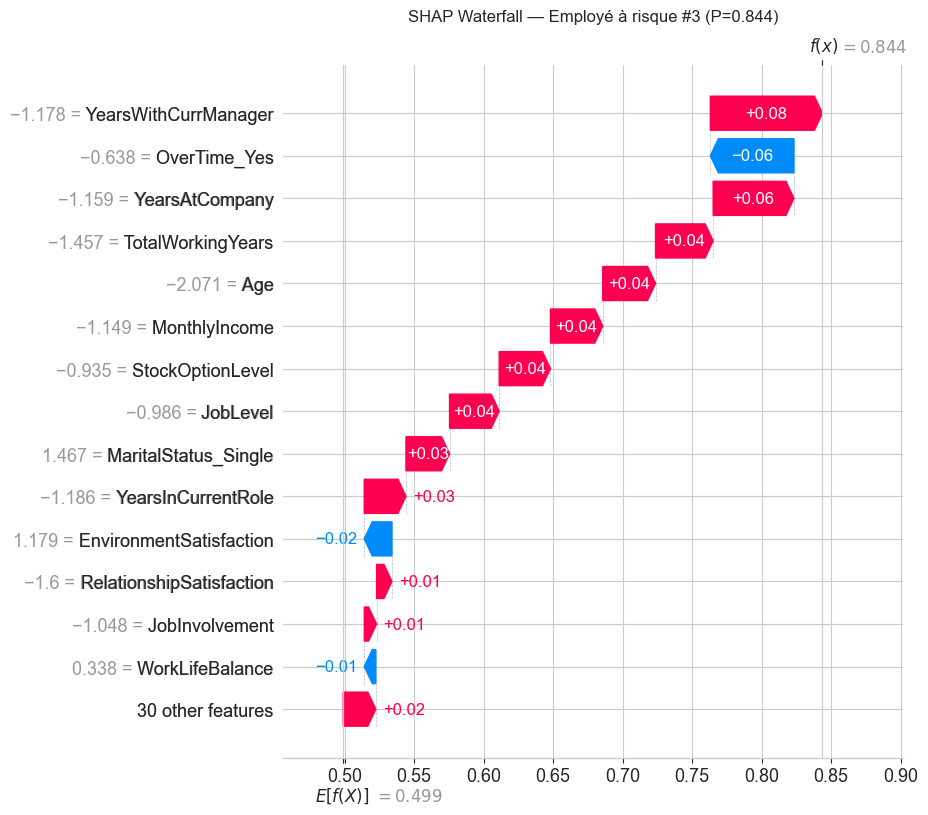

fig18_shap_waterfall_employe_3.png sauvegardé (300 dpi)


In [10]:
idx3 = top3_idx[2]
print(f"Employé #3 — Indice : {idx3} | P(départ) = {y_proba_test[idx3]:.3f} | "
      f"Réalité : {'Oui' if y_test.iloc[idx3]==1 else 'Non'}")

shap.plots.waterfall(shap_exp[idx3], max_display=15, show=False)
plt.title(f'SHAP Waterfall — Employé à risque #3 (P={y_proba_test[idx3]:.3f})', fontsize=12, pad=10)
plt.savefig('../figures/fig18_shap_waterfall_employe_3.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('fig18_shap_waterfall_employe_3.png sauvegardé (300 dpi)')

---
## Synthèse finale — Variables déterminantes du turnover

On consolide ici les enseignements de l'analyse SHAP pour formuler des recommandations concrètes
à destination des équipes RH.

In [11]:
# Top 15 variables par importance SHAP moyenne (|valeur SHAP| moyenne sur tous les employés du test)
mean_abs_shap = np.abs(shap_class1).mean(axis=0)
top15 = pd.DataFrame({
    'Variable': X_test_scaled.columns,
    'SHAP moyen (|valeur|)': mean_abs_shap
}).sort_values('SHAP moyen (|valeur|)', ascending=False).head(15).reset_index(drop=True)
top15.index += 1  # numérotation à partir de 1

print('Top 15 variables les plus déterminantes du turnover (Random Forest + SHAP) :')
print(top15.to_string())

print('\n' + '=' * 60)
print('RECOMMANDATIONS RH ISSUES DE L\'ANALYSE SHAP')
print('=' * 60)
v1, v2, v3 = top15.iloc[0]['Variable'], top15.iloc[1]['Variable'], top15.iloc[2]['Variable']
print(f'\n1. Variable la plus déterminante : {v1}')
print(f'2. 2e variable                    : {v2}')
print(f'3. 3e variable                    : {v3}')
print('\nCes variables représentent les principaux leviers d\'action pour les équipes RH :')
print('  -> Identifier les profils à risque avant qu\'ils ne démissionnent')
print('  -> Agir en priorité sur les variables modifiables (satisfaction, rémunération, OverTime)')
print('  -> Les variables non-modifiables (ancienneté, âge) servent à prioriser la surveillance')
print('\nProchaine étape (Notebook 4) : développement d\'un dashboard interactif')
print('pour visualiser les prédictions et les interprétations SHAP en temps réel.')

Top 15 variables les plus déterminantes du turnover (Random Forest + SHAP) :
                   Variable  SHAP moyen (|valeur|)
1              OverTime_Yes               0.075710
2      YearsWithCurrManager               0.043984
3          StockOptionLevel               0.040862
4                  JobLevel               0.027325
5      MaritalStatus_Single               0.026204
6            YearsAtCompany               0.025336
7           JobSatisfaction               0.025009
8                       Age               0.022027
9             MonthlyIncome               0.016340
10       YearsInCurrentRole               0.015879
11  EnvironmentSatisfaction               0.015878
12       NumCompaniesWorked               0.014255
13          WorkLifeBalance               0.012464
14        TotalWorkingYears               0.011356
15           JobInvolvement               0.009789

RECOMMANDATIONS RH ISSUES DE L'ANALYSE SHAP

1. Variable la plus déterminante : OverTime_Yes
2. 2e variabl

---
## Prochaine étape (Notebook 4)

Développement d'un **dashboard interactif** (Streamlit ou Dash) permettant aux équipes RH de :
- Visualiser les employés à risque détectés par le modèle
- Explorer les explications SHAP pour chaque profil individuel
- Simuler l'impact d'un changement de variable sur le risque prédit